In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline

import numpy as np
import sys, pickle, os, torch, cv2
import pydicom as dcm
# replace this path with path to GMIC
#sys.path.append("/path/to/GMIC")

from src.data_loading import loading
from src.modeling import gmic as gmic

from PIL import Image

Sally^Pink
L
CC


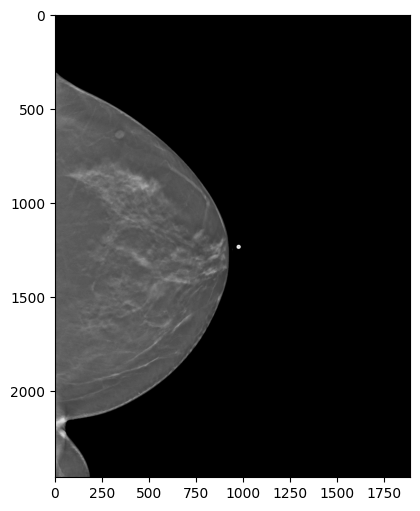

In [2]:
filePath = "single_data/dicom_exams/DBT-SallyAfter/2.25.38946483257757728473930748055098080826/2.25.201219780999166115125425598107454529380/1-1.dcm"
# filePath = "single_data/dicom_exams/DBT-SallyPrior/2.25.150024898330761854275119164874364274247/2.25.154814202124532790361185006613609999705/1-1.dcm"
ds = dcm.dcmread(filePath, force=True) # dicom dataset

arr = ds.pixel_array

fig, ax = plt.subplots(1, figsize=(8, 6))
ax.imshow(arr[33], cmap="gray")

print(ds.PatientName)
print(ds.PatientOrientation[1])
print(ds.ViewPosition)

In [3]:
filePath = "single_data/dicom_exams/DBT-SallyAfter/2.25.38946483257757728473930748055098080826/2.25.201219780999166115125425598107454529380/outputDicomSR.dcm"
# filePath = "single_data/dicom_exams/DBT-SallyPrior/2.25.150024898330761854275119164874364274247/2.25.154814202124532790361185006613609999705/outputDicomSR.dcm"
ds = dcm.dcmread(filePath, force=True) # dicom dataset

In [10]:
def plotPolyline(ax, ds, idx):
    seq4 = ds[0x0040, 0xa730][2]
    seq5 = ds[0x0040, 0xa730][3]
    print(seq5[0x0040, 0xa160].value)

    print(type(seq4))
    print(len(seq4))
    print(seq4[0x0070, 0x0022])

    arr = seq4[0x0070, 0x0022]
    print(arr.value)

    x = arr.value[::2]
    y = [2385-y for y in arr.value[1::2]]
    ax.plot(x, y, c="tab:green", label="{}".format(idx))

Lesion: asymmetry
<class 'pydicom.dataset.Dataset'>
6
(0070, 0022) Graphic Data                        FL: Array of 1286 elements
[607.0, 960.0, 606.0, 961.0, 605.0, 961.0, 604.0, 962.0, 603.0, 962.0, 602.0, 963.0, 601.0, 964.0, 600.0, 964.0, 599.0, 965.0, 598.0, 966.0, 597.0, 966.0, 596.0, 967.0, 595.0, 968.0, 594.0, 969.0, 593.0, 969.0, 592.0, 970.0, 591.0, 971.0, 590.0, 972.0, 589.0, 973.0, 588.0, 974.0, 587.0, 975.0, 586.0, 976.0, 585.0, 977.0, 585.0, 978.0, 584.0, 979.0, 583.0, 980.0, 582.0, 981.0, 582.0, 982.0, 581.0, 983.0, 580.0, 984.0, 580.0, 985.0, 579.0, 986.0, 578.0, 987.0, 578.0, 988.0, 577.0, 989.0, 577.0, 990.0, 576.0, 991.0, 576.0, 992.0, 577.0, 993.0, 577.0, 994.0, 578.0, 995.0, 578.0, 996.0, 579.0, 997.0, 580.0, 998.0, 579.0, 999.0, 578.0, 999.0, 577.0, 1000.0, 576.0, 1000.0, 575.0, 1000.0, 574.0, 1000.0, 573.0, 1001.0, 572.0, 1001.0, 571.0, 1001.0, 570.0, 1002.0, 569.0, 1002.0, 568.0, 1002.0, 567.0, 1003.0, 566.0, 1003.0, 565.0, 1004.0, 564.0, 1004.0, 564.0, 1005.0, 

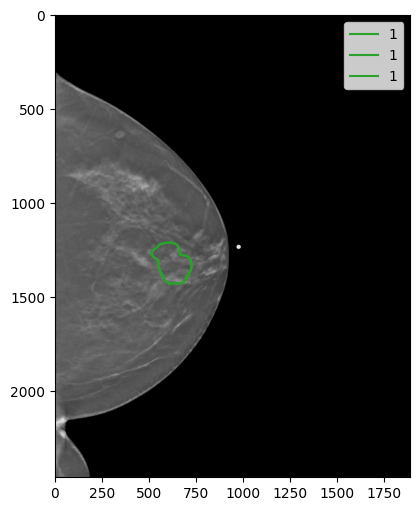

In [11]:
seq1 = ds[0x0040, 0xa730][0]
seq2 = seq1[0x0040, 0xa730][0]

for i in range(1,2):
    seq3 = seq2[0x0040, 0xa730][i]
    plotPolyline(ax, seq3, i)
ax.legend()
fig

In [7]:
print(seq2)

(0040, a010) Relationship Type                   CS: 'INFERRED FROM'
(0040, a040) Value Type                          CS: 'CONTAINER'
(0040, a043)  Concept Name Code Sequence  1 item(s) ---- 
   (0008, 0100) Code Value                          SH: '111034'
   (0008, 0102) Coding Scheme Designator            SH: 'DCM'
   (0008, 0104) Code Meaning                        LO: 'Individual Impression/Recommendation'
   ---------
(0040, a050) Continuity Of Content               CS: 'SEPARATE'
(0040, a730)  Content Sequence  2 item(s) ---- 
   (0040, a010) Relationship Type                   CS: 'CONTAINS'
   (0040, a040) Value Type                          CS: 'CONTAINER'
   (0040, a043)  Concept Name Code Sequence  1 item(s) ---- 
      (0008, 0100) Code Value                          SH: '111059'
      (0008, 0102) Coding Scheme Designator            SH: 'DCM'
      (0008, 0104) Code Meaning                        LO: 'Single Image Finding'
      ---------
   (0040, a050) Continuity Of Cont

In [2]:
with open('sample_data_vindr/exam_list.pkl', 'rb') as f:
    exam_list = pickle.load(f)

In [4]:
for exam in
    print(exam)

{'examID': 'ff797ae566e0c252a105853faab6e7cd', 'cancer_label': {'benign': 0, 'right_benign': 0, 'malignant': 0, 'left_benign': 0, 'unknown': 0, 'right_malignant': 0, 'left_malignant': 0}}
{'examID': 'ff02ce510218e943fba03aa113761fc4', 'cancer_label': {'benign': 0, 'right_benign': 0, 'malignant': 0, 'left_benign': 0, 'unknown': 0, 'right_malignant': 0, 'left_malignant': 0}}
{'examID': 'ff69fe368548fa21738bc1bf7fbe5860', 'cancer_label': {'benign': 0, 'right_benign': 0, 'malignant': 0, 'left_benign': 0, 'unknown': 0, 'right_malignant': 0, 'left_malignant': 0}}
{'examID': 'ff9e4f3aa02c617fd62e2ec6782b6246', 'cancer_label': {'benign': 0, 'right_benign': 0, 'malignant': 0, 'left_benign': 0, 'unknown': 0, 'right_malignant': 0, 'left_malignant': 0}}
{'examID': 'ff708a7a7d6af0f90b6b3ddee658f468', 'cancer_label': {'benign': 0, 'right_benign': 0, 'malignant': 0, 'left_benign': 0, 'unknown': 0, 'right_malignant': 0, 'left_malignant': 0}}
{'examID': 'fff2339ea4b5d2f1792672ba7d52b318', 'cancer_label

In [8]:
ds = dcm.dcmread("sample_data_vindr/dicom_exams/ff02ce510218e943fba03aa113761fc4/5b1dbb4ff19223769c689f1eed27255a.dicom")

/home/chris/miniconda3/envs/medken/lib/python3.11/site-packages/pydicom/valuerep.py:443: UserWarning: Invalid value for VR UI: '5b1dbb4ff19223769c689f1eed27255a'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warnings.warn(msg)
/home/chris/miniconda3/envs/medken/lib/python3.11/site-packages/pydicom/valuerep.py:443: UserWarning: Invalid value for VR UI: 'ff02ce510218e943fba03aa113761fc4'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warnings.warn(msg)
/home/chris/miniconda3/envs/medken/lib/python3.11/site-packages/pydicom/valuerep.py:443: UserWarning: Invalid value for VR UI: '2982a6134a86ce1531cda9e39ad094b6'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warnings.warn(msg)


Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 158
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: Digital Mammography X-Ray Image Storage - For Presentation
(0002, 0003) Media Storage SOP Instance UID      UI: 5b1dbb4ff19223769c689f1eed27255a
(0002, 0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.2.3.4
(0002, 0013) Implementation Version Name         SH: 'RadiAnt-2020.1.1'
-------------------------------------------------
(0008, 0018) SOP Instance UID                    UI: 5b1dbb4ff19223769c689f1eed27255a
(0008, 0060) Modality                            CS: 'MG'
(0008, 0068) Presentation Intent Type            CS: 'FOR PRESENTATION'
(0008, 0070) Manufacturer                        LO: 'SIEMENS'
(0008, 1090) Manufacturer's Model Name           LO: 'Mammomat Inspiration'
(0010, 0040) 